# CoTE Classwise Threshold + Minimum-area Calibration

Notebook Kaggle standalone này triển khai một giả thuyết tối ưu đồng thời `full-test` và `labeled-test`.

- Experiment: `cote_threshold_calibration`
- Base architecture: YOLO11n-seg + CoTE P4-only
- Dataset: shrimp-grouped, disease-stratified, leakage check bắt buộc
- Strong augmentation: giữ giống CoTE strong để ablation công bằng
- Mọi module, loss patch, calibration và YAML đều được định nghĩa inline
- Không import custom Python/YAML/notebook từ repository

Can thiệp: Sweep threshold riêng BG/WSSV, NMS IoU và diện tích mask tối thiểu trước khi đánh giá test.

Guardrail: `labeled_test_mask_map50` không giảm quá 0.01 và disease miss không tăng quá một ảnh; đồng thời ưu tiên giảm healthy FP-rate/FP masks per image.


In [20]:
# !pip install roboflow

# from roboflow import Roboflow
# rf = Roboflow(api_key="YOUR_ROBOFLOW_API_KEY")
# project = rf.workspace("lets-try-this").project("shrimpdishandsegv2")
# version = project.version(1)
# dataset = version.download("yolo26")
                

In [21]:
# /kaggle/working/shrimpDisHandSegV2-1

In [22]:
import importlib.util
import os
import subprocess
import sys

if importlib.util.find_spec('roboflow') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'roboflow'])

from roboflow import Roboflow

ROBOFLOW_API_KEY_DIRECT = ''  # Use Kaggle Secret ROBOFLOW_API_KEY or the environment variable.
ROBOFLOW_WORKSPACE = 'lets-try-this'
ROBOFLOW_PROJECT = 'shrimpdishandsegv2'
ROBOFLOW_VERSION = 1
ROBOFLOW_FORMAT = 'yolo26'


def get_roboflow_api_key():
    if ROBOFLOW_API_KEY_DIRECT.strip():
        return ROBOFLOW_API_KEY_DIRECT.strip()
    try:
        from kaggle_secrets import UserSecretsClient
        key = UserSecretsClient().get_secret('ROBOFLOW_API_KEY')
        if key:
            return key
    except Exception:
        pass
    return os.environ.get('ROBOFLOW_API_KEY', '').strip()


api_key = get_roboflow_api_key()
if not api_key:
    raise RuntimeError(
        'Missing Roboflow API key. Add a Kaggle Secret named ROBOFLOW_API_KEY, '
        'set the ROBOFLOW_API_KEY environment variable, or temporarily fill ROBOFLOW_API_KEY_DIRECT.'
    )

rf = Roboflow(api_key=api_key)
project = rf.workspace(ROBOFLOW_WORKSPACE).project(ROBOFLOW_PROJECT)
version = project.version(ROBOFLOW_VERSION)
dataset = version.download(ROBOFLOW_FORMAT)


loading Roboflow workspace...
loading Roboflow project...


In [23]:
import os
import random
import re
import shutil
from collections import defaultdict, Counter
from pathlib import Path

SEED = 42
random.seed(SEED)

base_path = '/kaggle/working/shrimpDisHandSegV2-1'
train_path = os.path.join(base_path, 'train')
IMAGE_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')

# Prevent leakage from multiple photos of the same shrimp.
# Expected original filename: <diseasename>-<shrimpid>-img-<imgnum>.jpg
# Roboflow may export names like <diseasename>-<shrimpid>-img-<imgnum>_jpg.rf.<hash>.jpg.
# Example disease names: Healthy, BG, WSSV_BG, WSSV.
GROUP_SPLIT_BY_SHRIMP = True
GROUP_STRATIFY_BY_DISEASE = True
REBUILD_SPLIT_FROM_ALL_SPLITS = True
TRAIN_RATIO = 0.80
VAL_RATIO = 0.10

SHRIMP_NAME_PATTERN = re.compile(
    r'^(?P<disease>Healthy|BG|WSSV_BG|WSSV)-(?P<shrimp_id>.+)-img-(?P<img_num>\d+)$',
    re.IGNORECASE,
)


def normalize_roboflow_stem(stem):
    """Recover the original filename stem from Roboflow-exported names."""
    stem = re.sub(r'_(jpg|jpeg|png|bmp|webp)\.rf\.[0-9a-f]+$', '', stem, flags=re.IGNORECASE)
    stem = re.sub(r'\.rf\.[0-9a-f]+$', '', stem, flags=re.IGNORECASE)
    return stem


for split in ['train', 'valid', 'test']:
    for sub in ['images', 'labels']:
        os.makedirs(os.path.join(base_path, split, sub), exist_ok=True)


def parse_shrimp_group_key(image_name):
    """Return a stable group key so all images from one shrimp stay in one split."""
    stem = normalize_roboflow_stem(Path(image_name).stem)
    match = SHRIMP_NAME_PATTERN.match(stem)
    if not match:
        return f'unparsed::{Path(image_name).stem}', 'unparsed', None, None

    disease = match.group('disease')
    shrimp_id = match.group('shrimp_id')
    img_num = int(match.group('img_num'))
    group_key = f'{disease.lower()}::{shrimp_id}'
    return group_key, disease, shrimp_id, img_num


def image_files_in_split(split):
    image_dir = Path(base_path) / split / 'images'
    return sorted(
        p for p in image_dir.iterdir()
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    )


def move_image_and_label(image_path, target_split):
    target_img_dir = Path(base_path) / target_split / 'images'
    target_lbl_dir = Path(base_path) / target_split / 'labels'
    target_img_dir.mkdir(parents=True, exist_ok=True)
    target_lbl_dir.mkdir(parents=True, exist_ok=True)

    label_name = f'{image_path.stem}.txt'
    label_src = image_path.parent.parent / 'labels' / label_name
    image_dst = target_img_dir / image_path.name
    label_dst = target_lbl_dir / label_name

    if image_path.resolve() != image_dst.resolve():
        if image_dst.exists():
            raise FileExistsError(f'Duplicate image destination would be overwritten: {image_dst}')
        shutil.move(str(image_path), str(image_dst))

    if label_src.exists():
        if label_src.resolve() != label_dst.resolve():
            if label_dst.exists():
                raise FileExistsError(f'Duplicate label destination would be overwritten: {label_dst}')
            shutil.move(str(label_src), str(label_dst))
    else:
        label_dst.write_text('')


def rebuild_train_pool_from_all_splits():
    all_images = []
    for split in ['train', 'valid', 'test']:
        all_images.extend(image_files_in_split(split))

    for image_path in sorted(all_images):
        move_image_and_label(image_path, 'train')

    return image_files_in_split('train')


def remove_yolo_label_caches(root):
    for cache_path in Path(root).glob('**/*.cache'):
        cache_path.unlink()
        print(f'Removed stale cache: {cache_path}')


def disease_for_group(filenames):
    diseases = []
    for filename in filenames:
        _, disease, _, _ = parse_shrimp_group_key(filename)
        diseases.append(disease)
    counts = Counter(diseases)
    if len(counts) > 1:
        print(f'Warning: group has mixed disease names: {dict(counts)}')
    return counts.most_common(1)[0][0]


def split_one_stratum(items):
    n = len(items)
    train_count = int(TRAIN_RATIO * n)
    val_count = int(VAL_RATIO * n)
    test_count = n - train_count - val_count

    if n >= 3:
        if val_count == 0:
            val_count = 1
            train_count -= 1
        if test_count == 0:
            test_count = 1
            train_count -= 1
    if train_count < 1 and n > 0:
        train_count = 1
    while train_count + val_count + test_count > n:
        train_count -= 1
    test_count = n - train_count - val_count

    return (
        items[:train_count],
        items[train_count:train_count + val_count],
        items[train_count + val_count:],
    )


def grouped_stratified_split(group_items):
    strata = defaultdict(list)
    for group_key, filenames in group_items:
        strata[disease_for_group(filenames)].append((group_key, filenames))

    split_to_groups = {'train': [], 'valid': [], 'test': []}
    rng = random.Random(SEED)
    for disease, items in sorted(strata.items()):
        items = sorted(items, key=lambda item: item[0])
        rng.shuffle(items)
        train_items, val_items, test_items = split_one_stratum(items)
        split_to_groups['train'].extend(train_items)
        split_to_groups['valid'].extend(val_items)
        split_to_groups['test'].extend(test_items)
        print(
            f'  - {disease}: {len(train_items)} train groups, '
            f'{len(val_items)} valid groups, {len(test_items)} test groups'
        )

    for split in split_to_groups:
        split_to_groups[split] = sorted(split_to_groups[split], key=lambda item: item[0])
    return split_to_groups


def grouped_random_split(group_items):
    group_items = sorted(group_items, key=lambda item: item[0])
    random.Random(SEED).shuffle(group_items)
    n_groups = len(group_items)
    train_group_count = int(TRAIN_RATIO * n_groups)
    val_group_count = int(VAL_RATIO * n_groups)
    return {
        'train': group_items[:train_group_count],
        'valid': group_items[train_group_count:train_group_count + val_group_count],
        'test': group_items[train_group_count + val_group_count:],
    }


def split_summary(split_groups):
    group_diseases = Counter()
    image_diseases = Counter()
    for _, filenames in split_groups:
        group_diseases[disease_for_group(filenames)] += 1
        for filename in filenames:
            _, disease, _, _ = parse_shrimp_group_key(filename)
            image_diseases[disease] += 1
    return group_diseases, image_diseases


def split_grouped_by_shrimp():
    if REBUILD_SPLIT_FROM_ALL_SPLITS:
        image_paths = rebuild_train_pool_from_all_splits()
    else:
        image_paths = image_files_in_split('train')

    groups = defaultdict(list)
    disease_counts = Counter()
    unparsed = []

    for image_path in image_paths:
        group_key, disease, shrimp_id, img_num = parse_shrimp_group_key(image_path.name)
        groups[group_key].append(image_path.name)
        disease_counts[disease] += 1
        if disease == 'unparsed':
            unparsed.append(image_path.name)

    group_items = sorted(groups.items(), key=lambda item: item[0])
    if GROUP_STRATIFY_BY_DISEASE:
        print('Building shrimp-grouped, disease-stratified split:')
        split_to_groups = grouped_stratified_split(group_items)
    else:
        print('Building shrimp-grouped random split:')
        split_to_groups = grouped_random_split(group_items)

    for split, split_groups in split_to_groups.items():
        for _, filenames in split_groups:
            for filename in filenames:
                move_image_and_label(Path(base_path) / 'train' / 'images' / filename, split)

    print('Shrimp-grouped split complete:')
    for split, split_groups in split_to_groups.items():
        image_count = sum(len(filenames) for _, filenames in split_groups)
        group_diseases, image_diseases = split_summary(split_groups)
        print(f'  - {split}: {len(split_groups)} shrimp groups, {image_count} images')
        print(f'    group disease counts: {dict(sorted(group_diseases.items()))}')
        print(f'    image disease counts: {dict(sorted(image_diseases.items()))}')

    print('Source filename disease counts before split:', dict(sorted(disease_counts.items())))
    if unparsed:
        print(f'Warning: {len(unparsed)} filenames did not match the shrimp naming pattern. They were split as single-image groups.')
        print('First unparsed examples:', unparsed[:10])

    group_to_split = {}
    leakage = []
    for split in ['train', 'valid', 'test']:
        for image_path in image_files_in_split(split):
            group_key, *_ = parse_shrimp_group_key(image_path.name)
            previous_split = group_to_split.setdefault(group_key, split)
            if previous_split != split:
                leakage.append((group_key, previous_split, split, image_path.name))

    if leakage:
        raise RuntimeError(f'Shrimp-level split leakage detected: {leakage[:10]}')
    print('Shrimp-level leakage check passed.')
    remove_yolo_label_caches(base_path)


if GROUP_SPLIT_BY_SHRIMP:
    split_grouped_by_shrimp()
else:
    valid_images_dir = Path(base_path) / 'valid' / 'images'
    test_images_dir = Path(base_path) / 'test' / 'images'

    if not any(valid_images_dir.glob('*')) and not any(test_images_dir.glob('*')):
        image_files = sorted(
            f for f in os.listdir(os.path.join(train_path, 'images'))
            if f.lower().endswith(IMAGE_EXTENSIONS)
        )
        random.shuffle(image_files)

        train_count = int(0.8 * len(image_files))
        val_count = int(0.1 * len(image_files))
        val_files = image_files[train_count:train_count + val_count]
        test_files = image_files[train_count + val_count:]

        def move_files(files, target_split):
            for f in files:
                move_image_and_label(Path(train_path) / 'images' / f, target_split)

        move_files(val_files, 'valid')
        move_files(test_files, 'test')
        print(f"Image-level split complete: {len(image_files) - len(val_files) - len(test_files)} train, {len(val_files)} val, {len(test_files)} test")
        remove_yolo_label_caches(base_path)
    else:
        print('Existing valid/test split detected. Keeping downloaded split.')


Building shrimp-grouped, disease-stratified split:
  - BG: 60 train groups, 7 valid groups, 8 test groups
  - Healthy: 113 train groups, 14 valid groups, 15 test groups
  - WSSV: 94 train groups, 11 valid groups, 13 test groups
  - WSSV_BG: 64 train groups, 8 valid groups, 9 test groups
Shrimp-grouped split complete:
  - train: 331 shrimp groups, 905 images
    group disease counts: {'BG': 60, 'Healthy': 113, 'WSSV': 94, 'WSSV_BG': 64}
    image disease counts: {'BG': 153, 'Healthy': 321, 'WSSV': 258, 'WSSV_BG': 173}
  - valid: 40 shrimp groups, 115 images
    group disease counts: {'BG': 7, 'Healthy': 14, 'WSSV': 11, 'WSSV_BG': 8}
    image disease counts: {'BG': 21, 'Healthy': 41, 'WSSV': 32, 'WSSV_BG': 21}
  - test: 45 shrimp groups, 129 images
    group disease counts: {'BG': 8, 'Healthy': 15, 'WSSV': 13, 'WSSV_BG': 9}
    image disease counts: {'BG': 24, 'Healthy': 41, 'WSSV': 38, 'WSSV_BG': 26}
Source filename disease counts before split: {'BG': 198, 'Healthy': 403, 'WSSV': 328, 

In [24]:
# -- Define shape-safe CoTE improvements and patch Ultralytics inline -----------
import importlib.util
import inspect
import math
import subprocess
import sys
from pathlib import Path
from typing import Iterable

VENDORED_ULTRALYTICS = Path.cwd() / 'ultralytics'
if (VENDORED_ULTRALYTICS / 'ultralytics' / '__init__.py').exists() and str(VENDORED_ULTRALYTICS) not in sys.path:
    sys.path.insert(0, str(VENDORED_ULTRALYTICS))

loaded_ultralytics = sys.modules.get('ultralytics')
if loaded_ultralytics is not None and not hasattr(loaded_ultralytics, '__version__'):
    for module_name in list(sys.modules):
        if module_name == 'ultralytics' or module_name.startswith('ultralytics.'):
            del sys.modules[module_name]

if importlib.util.find_spec('ultralytics') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'ultralytics'])

import torch
import torch.nn as nn


def _resolve_channels(c1=None, channels=None):
    value = channels if channels is not None else c1
    if value is None or int(value) <= 0:
        raise ValueError(f'A positive channel count is required, got {value!r}')
    return int(value)


def _odd_kernel(value):
    value = int(value)
    return value if value % 2 else value + 1


class ECAGate(nn.Module):
    """Efficient Channel Attention weights with shape [B,C,1,1]."""

    def __init__(self, c1=None, k_size=3, channels=None):
        super().__init__()
        self.channels = _resolve_channels(c1, channels)
        k_size = _odd_kernel(k_size)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.conv = nn.Conv1d(1, 1, kernel_size=k_size, padding=(k_size - 1) // 2, bias=False)

    def forward(self, x):
        if x.ndim != 4 or x.shape[1] != self.channels:
            raise RuntimeError(f'ECAGate expected [B,{self.channels},H,W], got {tuple(x.shape)}')
        weight = self.pool(x).squeeze(-1).transpose(1, 2).contiguous()
        weight = self.conv(weight).transpose(1, 2).unsqueeze(-1).contiguous()
        return torch.sigmoid(weight)


class _SpatialDescriptorGate(nn.Module):
    def __init__(self, kernel_size=5):
        super().__init__()
        kernel_size = _odd_kernel(kernel_size)
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=(kernel_size - 1) // 2, bias=False)

    def forward(self, x):
        descriptor = torch.cat((x.mean(1, keepdim=True), x.amax(1, keepdim=True)), dim=1)
        return torch.sigmoid(self.conv(descriptor))


class TripletLiteGate(nn.Module):
    """Triplet-style attention map preserving [B,C,H,W]."""

    def __init__(self, c1=None, k=5, channels=None):
        super().__init__()
        self.channels = _resolve_channels(c1, channels)
        k = _odd_kernel(k)
        self.hw = nn.Sequential(
            nn.Conv2d(self.channels, self.channels, k, padding=(k - 1) // 2, groups=self.channels, bias=False),
            nn.Conv2d(self.channels, self.channels, 1, bias=False),
            nn.Sigmoid(),
        )
        self.cw = _SpatialDescriptorGate(k)
        self.hc = _SpatialDescriptorGate(k)

    def forward(self, x):
        if x.ndim != 4 or x.shape[1] != self.channels:
            raise RuntimeError(f'TripletLiteGate expected [B,{self.channels},H,W], got {tuple(x.shape)}')
        b, c, h, w = x.shape
        gate_hw = self.hw(x)
        gate_cw = self.cw(x.permute(0, 2, 1, 3).contiguous()).permute(0, 2, 1, 3).contiguous()
        gate_hc = self.hc(x.permute(0, 3, 2, 1).contiguous()).permute(0, 3, 2, 1).contiguous()
        return (gate_hw + gate_cw.expand(b, c, h, w) + gate_hc.expand(b, c, h, w)) / 3.0


class CoTEGate(nn.Module):
    """Consensus-Regularized Triplet-ECA residual gate."""

    def __init__(self, c1, eca_k=3, triplet_k=5, alpha_init=0.20, gamma_init=0.0):
        super().__init__()
        channels = _resolve_channels(c1)
        self.triplet = TripletLiteGate(channels, k=triplet_k)
        self.eca = ECAGate(channels, k_size=eca_k)
        self.smooth = nn.AvgPool2d(3, stride=1, padding=1)
        self.lambda_t = nn.Parameter(torch.tensor(1.0))
        self.lambda_c = nn.Parameter(torch.tensor(1.0))
        self.alpha = nn.Parameter(torch.tensor(float(alpha_init)))
        self.gamma = nn.Parameter(torch.tensor(float(gamma_init)))

    def forward(self, x):
        triplet = self.triplet(x)
        channel = self.eca(x).expand_as(x)
        disagreement = self.smooth(torch.abs(triplet - channel))
        gate = torch.sigmoid(self.lambda_t * triplet + self.lambda_c * channel - self.alpha * disagreement)
        return x + self.gamma * x * gate


class CoTEECARescue(nn.Module):
    """Report proposal: y = x + alpha * ECA(CoTE(x)), with alpha zero-init."""

    def __init__(
        self, c1, cote_eca_k=3, triplet_k=5, cote_alpha=0.20,
        cote_gamma=1.0, rescue_eca_k=3, rescue_alpha_init=0.0,
    ):
        super().__init__()
        channels = _resolve_channels(c1)
        self.cote = CoTEGate(channels, cote_eca_k, triplet_k, cote_alpha, cote_gamma)
        self.rescue_eca = ECAGate(channels, rescue_eca_k)
        self.rescue_alpha = nn.Parameter(torch.tensor(float(rescue_alpha_init)))

    def forward(self, x):
        z = self.cote(x)
        rescued = z * self.rescue_eca(z)
        return x + self.rescue_alpha * rescued


class ResidualCalibratedCoTE(nn.Module):
    """Report proposal: y = x + sigmoid(g) * (CoTE(x) - x)."""

    def __init__(
        self, c1, eca_k=3, triplet_k=5, cote_alpha=0.20,
        cote_gamma=1.0, init_logit=-4.0, channelwise=False,
    ):
        super().__init__()
        channels = _resolve_channels(c1)
        self.channels = channels
        self.cote = CoTEGate(channels, eca_k, triplet_k, cote_alpha, cote_gamma)
        shape = (1, channels, 1, 1) if bool(channelwise) else (1,)
        self.g = nn.Parameter(torch.full(shape, float(init_logit)))

    def forward(self, x):
        z = self.cote(x)
        gamma = torch.sigmoid(self.g)
        return x + gamma * (z - x)


RESEARCH_ATTENTION_MODULES = (ECAGate, TripletLiteGate, CoTEGate, CoTEECARescue, ResidualCalibratedCoTE)


def module_name_list(modules: Iterable[type[nn.Module]] = RESEARCH_ATTENTION_MODULES):
    return [module.__name__ for module in modules]


EXPERIMENT_NAME = 'cote_threshold_calibration'
MODULE_FOLDER_NAME = 'improving_full_and_labeled_test'


def register_research_attention_inline():
    import ultralytics.nn.modules as nn_modules
    import ultralytics.nn.modules.conv as conv_module
    import ultralytics.nn.tasks as tasks_module

    for module_cls in RESEARCH_ATTENTION_MODULES:
        setattr(tasks_module, module_cls.__name__, module_cls)
        setattr(nn_modules, module_cls.__name__, module_cls)
        setattr(conv_module, module_cls.__name__, module_cls)
    nn_modules.__all__ = list(set(list(getattr(nn_modules, '__all__', [])) + module_name_list()))
    tasks_module.RESEARCH_ATTENTION_MODULES = RESEARCH_ATTENTION_MODULES

    if getattr(tasks_module, '_shrimp_labeled_improvement_parse_model_patched', False):
        return
    source = inspect.getsource(tasks_module.parse_model)
    insert = """        elif m in RESEARCH_ATTENTION_MODULES:
            c1 = ch[f]
            c2 = c1
            args = [c1, *args]
"""
    if 'elif m in RESEARCH_ATTENTION_MODULES:' not in source:
        markers = (
            "        elif m in frozenset(\n            {\n                Detect,",
            "        elif m is SemanticSegment:",
            "        elif m in frozenset({TorchVision, Index}):",
        )
        for marker in markers:
            if marker in source:
                source = source.replace(marker, insert + marker, 1)
                break
        else:
            raise RuntimeError('Could not patch ultralytics.nn.tasks.parse_model for inline CoTE modules.')
    exec(compile(source, '<improving_full_and_labeled_test_parse_model>', 'exec'), tasks_module.__dict__)
    tasks_module._shrimp_labeled_improvement_parse_model_patched = True


register_research_attention_inline()
print('Inline modules registered:', ', '.join(module_name_list()))
print('Experiment:', EXPERIMENT_NAME)


Inline modules registered: ECAGate, TripletLiteGate, CoTEGate, CoTEECARescue, ResidualCalibratedCoTE
Experiment: cote_threshold_calibration


In [25]:
# -- Create the model YAML inline and verify build/forward shapes ----------------
from pathlib import Path

import torch
from ultralytics import YOLO
import ultralytics.nn.tasks as tasks_module

YAML_CONTENT = 'nc: 2\ndepth_multiple: 1.0\nwidth_multiple: 1.0\nbackbone:\n- - -1\n  - 1\n  - Conv\n  - - 16\n    - 3\n    - 2\n- - -1\n  - 1\n  - Conv\n  - - 32\n    - 3\n    - 2\n- - -1\n  - 1\n  - C3k2\n  - - 64\n    - false\n    - 0.25\n- - -1\n  - 1\n  - Conv\n  - - 64\n    - 3\n    - 2\n- - -1\n  - 1\n  - C3k2\n  - - 64\n    - false\n    - 0.25\n- - -1\n  - 1\n  - Conv\n  - - 128\n    - 3\n    - 2\n- - -1\n  - 1\n  - C3k2\n  - - 128\n    - false\n    - 0.25\n- - -1\n  - 1\n  - Conv\n  - - 256\n    - 3\n    - 2\n- - -1\n  - 1\n  - C3k2\n  - - 256\n    - true\n- - -1\n  - 1\n  - SPPF\n  - - 256\n    - 5\n- - -1\n  - 1\n  - C2PSA\n  - - 256\nhead:\n- - -1\n  - 1\n  - nn.Upsample\n  - - null\n    - 2\n    - nearest\n- - - -1\n    - 6\n  - 1\n  - Concat\n  - - 1\n- - -1\n  - 1\n  - C3k2\n  - - 128\n    - false\n- - -1\n  - 1\n  - nn.Upsample\n  - - null\n    - 2\n    - nearest\n- - - -1\n    - 4\n  - 1\n  - Concat\n  - - 1\n- - -1\n  - 1\n  - C3k2\n  - - 64\n    - false\n- - -1\n  - 1\n  - Conv\n  - - 64\n    - 3\n    - 2\n- - - -1\n    - 13\n  - 1\n  - Concat\n  - - 1\n- - -1\n  - 1\n  - C3k2\n  - - 128\n    - false\n- - -1\n  - 1\n  - Conv\n  - - 128\n    - 3\n    - 2\n- - - -1\n    - 10\n  - 1\n  - Concat\n  - - 1\n- - -1\n  - 1\n  - C3k2\n  - - 256\n    - true\n- - 19\n  - 1\n  - CoTEGate\n  - - 3\n    - 5\n    - 0.2\n    - 0.0\n- - - 16\n    - 23\n    - 22\n  - 1\n  - Segment\n  - - nc\n    - 32\n    - 64\n'
yaml_dir = Path.cwd() / 'improving_full_and_labeled_test' / 'generated_yamls'
yaml_dir.mkdir(parents=True, exist_ok=True)
yaml_path = yaml_dir / f'{EXPERIMENT_NAME}.yaml'
yaml_path.write_text(YAML_CONTENT, encoding='utf-8')
MODEL_YAML = str(yaml_path)
print('Inline YAML materialized at runtime:', MODEL_YAML)


def _flatten_tensors(value):
    if torch.is_tensor(value):
        yield value
    elif isinstance(value, (list, tuple)):
        for item in value:
            yield from _flatten_tensors(item)
    elif isinstance(value, dict):
        for item in value.values():
            yield from _flatten_tensors(item)


def sanity_check_yolo_seg_model_inline(model_yaml, imgsz=640, device=None):
    register_research_attention_inline()
    device = device or ('cuda' if torch.cuda.is_available() else 'cpu')
    yolo = YOLO(str(model_yaml))
    yolo.model.to(device).eval()

    dummy = torch.zeros(1, 3, int(imgsz), int(imgsz), device=device)
    with torch.no_grad():
        output = yolo.model(dummy)
    tensors = list(_flatten_tensors(output))
    if not tensors:
        raise RuntimeError('YOLO segmentation forward returned no tensors.')
    for index, tensor in enumerate(tensors):
        if not torch.isfinite(tensor).all():
            raise RuntimeError(f'Non-finite output tensor #{index} with shape {tuple(tensor.shape)}')

    expected = 'CoTEGate'
    found = [m for m in yolo.model.modules() if m.__class__.__name__ == expected]
    if len(found) != 1:
        raise RuntimeError(f'Expected exactly one {expected} at P4, found {len(found)}.')

    probe = torch.randn(2, 128, 40, 40, device=device)
    found[0].eval()
    with torch.no_grad():
        probe_out = found[0](probe)
    if probe_out.shape != probe.shape:
        raise RuntimeError(f'Shape mismatch: {tuple(probe.shape)} -> {tuple(probe_out.shape)}')

    # YOLO(yaml) has not yet received trainer args, so criterion construction is
    # intentionally deferred to train(). Verify the class bound in tasks instead.
    criterion_name = tasks_module.v8SegmentationLoss.__name__
    params = sum(parameter.numel() for parameter in yolo.model.parameters())
    print(f'PASS build + forward: module={expected}, shape={tuple(probe_out.shape)}, criterion={criterion_name}')
    print(f'Output tensors={len(tensors)}, parameters={params:,}')
    return {'status': 'PASS', 'module': expected, 'params': params, 'criterion': criterion_name}


SANITY_RESULT = sanity_check_yolo_seg_model_inline(MODEL_YAML, imgsz=640)


Inline YAML materialized at runtime: /kaggle/working/improving_full_and_labeled_test/generated_yamls/cote_threshold_calibration.yaml
PASS build + forward: module=CoTEGate, shape=(2, 128, 40, 40), criterion=v8SegmentationLoss
Output tensors=9, parameters=2,732,209


In [26]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec('ultralytics') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'ultralytics'])

from ultralytics import YOLO
import os
from pathlib import Path

base_path = '/kaggle/working/shrimpDisHandSegV2-1'
data_yaml_path = os.path.join(base_path, 'data.yaml')

# Keep the model name and run name tied together so reports are not mislabeled.
# Comment in/out models here for the baseline run.
YOLO_MODELS = [MODEL_YAML]

YOLO_MODEL = MODEL_YAML
MODEL_STEM = EXPERIMENT_NAME
RUN_BASE_NAME = EXPERIMENT_NAME

# Load once here as a smoke check. Training cells instantiate fresh models per experiment.
model = YOLO(YOLO_MODEL)
print('Configured segmentation models:')
for configured_model in YOLO_MODELS:
    print(f'  - {configured_model}')
print(f'Run name prefix: {RUN_BASE_NAME}')

Configured segmentation models:
  - /kaggle/working/improving_full_and_labeled_test/generated_yamls/cote_threshold_calibration.yaml
Run name prefix: cote_threshold_calibration


In [27]:
import yaml

# Update data.yaml to use correct paths
with open(data_yaml_path, 'r') as f:
    content = yaml.safe_load(f)

content['train'] = '/kaggle/working/shrimpDisHandSegV2-1/train/images'
content['val'] = '/kaggle/working/shrimpDisHandSegV2-1/valid/images'
content['test'] = '/kaggle/working/shrimpDisHandSegV2-1/test/images'

with open(data_yaml_path, 'w') as f:
    yaml.dump(content, f)

print("data.yaml updated with absolute paths.")

data.yaml updated with absolute paths.


### Exploratory Data Analysis (EDA)
We will analyze the dataset to understand the class distribution and visualize some sample images with their masks.

In [28]:
import os
import yaml
import matplotlib.pyplot as plt
import cv2
import numpy as np
from collections import Counter
from pathlib import Path

# Load class names from data.yaml. Empty label files are healthy shrimp negatives.
with open(data_yaml_path, 'r') as f:
    data_config = yaml.safe_load(f)

class_names = data_config.get('names', [])
HEALTHY_CLASS_NAME = 'healthy'
print(f"Disease mask classes found: {class_names}")
print(f"Empty label files will be treated as: {HEALTHY_CLASS_NAME} shrimp negatives")


def split_label_stats(label_dir):
    instance_counts = Counter()
    labeled_images = 0
    healthy_images = 0
    missing_or_empty = 0
    label_dir = Path(label_dir)
    for label_file in label_dir.glob('*.txt'):
        lines = [line.strip() for line in label_file.read_text().splitlines() if line.strip()]
        if not lines:
            healthy_images += 1
            continue
        labeled_images += 1
        for line in lines:
            class_id = int(float(line.split()[0]))
            instance_counts[class_id] += 1
    return {
        'instance_counts': instance_counts,
        'labeled_images': labeled_images,
        'healthy_images': healthy_images,
        'total_label_files': labeled_images + healthy_images,
    }


stats = {}
for split in ['train', 'valid', 'test']:
    label_dir = os.path.join(base_path, split, 'labels')
    stats[split] = split_label_stats(label_dir)

for split, split_stats in stats.items():
    print(f"\n{split.capitalize()} Split:")
    print(f"  - labeled disease images: {split_stats['labeled_images']}")
    print(f"  - healthy negative images: {split_stats['healthy_images']}")
    for cid, count in split_stats['instance_counts'].items():
        name = class_names[cid] if cid < len(class_names) else f"Unknown({cid})"
        print(f"  - {name}: {count} mask instances")

Disease mask classes found: ['BG', 'WSSV']
Empty label files will be treated as: healthy shrimp negatives

Train Split:
  - labeled disease images: 584
  - healthy negative images: 321
  - WSSV: 446 mask instances
  - BG: 364 mask instances

Valid Split:
  - labeled disease images: 74
  - healthy negative images: 41
  - WSSV: 56 mask instances
  - BG: 46 mask instances

Test Split:
  - labeled disease images: 88
  - healthy negative images: 41
  - WSSV: 67 mask instances
  - BG: 52 mask instances


### Visualizing Class Imbalance
An imbalanced dataset can cause the model to be biased. Let's visualize the distribution across our splits.

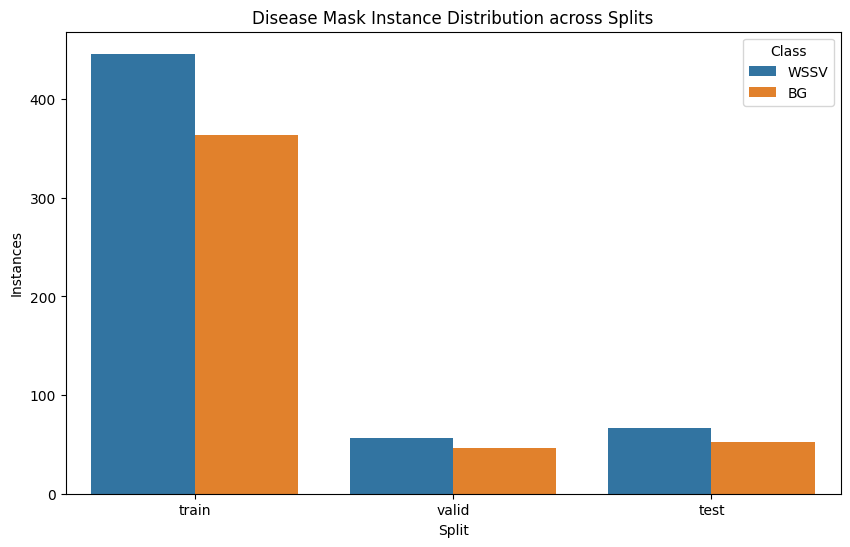

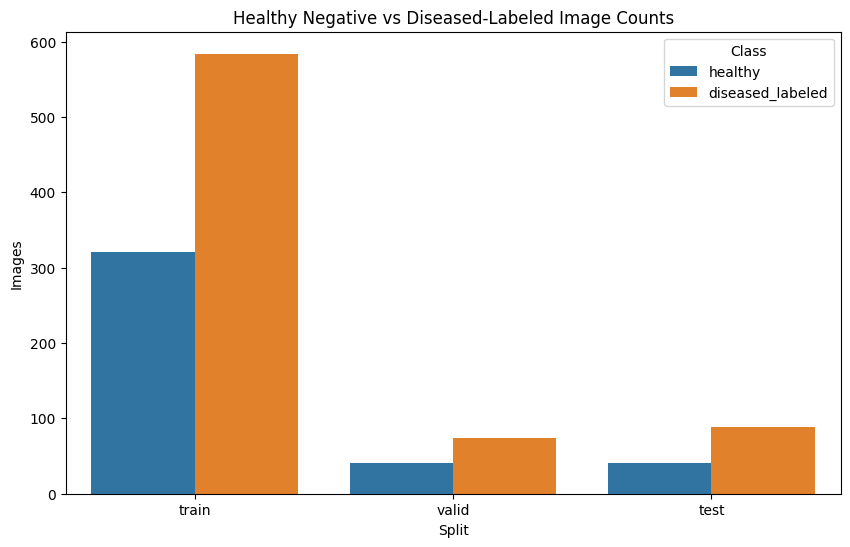

Train: 44.94% blackgill instances; 35.47% healthy negative images
Valid: 45.10% blackgill instances; 35.65% healthy negative images
Test: 43.70% blackgill instances; 31.78% healthy negative images


In [29]:
import pandas as pd
import seaborn as sns

instance_plot_data = []
image_plot_data = []
for split, split_stats in stats.items():
    image_plot_data.append({'Split': split, 'Class': HEALTHY_CLASS_NAME, 'Images': split_stats['healthy_images']})
    image_plot_data.append({'Split': split, 'Class': 'diseased_labeled', 'Images': split_stats['labeled_images']})
    for cid, count in split_stats['instance_counts'].items():
        instance_plot_data.append({'Split': split, 'Class': class_names[cid], 'Instances': count})

if instance_plot_data:
    df_instances = pd.DataFrame(instance_plot_data)
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_instances, x='Split', y='Instances', hue='Class')
    plt.title('Disease Mask Instance Distribution across Splits')
    plt.show()

if image_plot_data:
    df_images = pd.DataFrame(image_plot_data)
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_images, x='Split', y='Images', hue='Class')
    plt.title('Healthy Negative vs Diseased-Labeled Image Counts')
    plt.show()

for split, split_stats in stats.items():
    total_instances = sum(split_stats['instance_counts'].values())
    blackgill_ratio = (split_stats['instance_counts'].get(0, 0) / max(1, total_instances)) * 100
    healthy_ratio = (split_stats['healthy_images'] / max(1, split_stats['total_label_files'])) * 100
    print(f"{split.capitalize()}: {blackgill_ratio:.2f}% blackgill instances; {healthy_ratio:.2f}% healthy negative images")

#### Observations:
1. **High Disease-Class Imbalance**: `blackgill` is a small fraction of disease mask instances.
2. **Healthy Negatives Are Real Data**: Empty label files are healthy shrimp images, not missing annotations.
3. **Evaluation Must Split Responsibilities**:
   - Diseased/labeled images should be evaluated with box/mask mAP and recall.
   - Healthy/empty-label images should be evaluated with false-positive rate and false-positive masks per image.

**Recommendation**: Keep healthy images in training as negative controls, but report healthy false-positive metrics separately instead of mixing them into disease mask mAP interpretation.

### Optional Minority RandAugment Oversampling
The baseline starts with `ENABLE_MINORITY_OVERSAMPLING = False`. Turn it on later to create RandAugment-based minority samples. The implementation uses label-preserving photometric RandAugment operations so segmentation polygons remain valid.


In [30]:
import cv2
import os
import random
from pathlib import Path
from PIL import Image, ImageEnhance, ImageOps

IMAGE_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')

ENABLE_MINORITY_OVERSAMPLING = False
MINORITY_CLASS_ID = 0
MINORITY_OVERSAMPLING_MULTIPLIER = 8
RAND_AUGMENT_NUM_OPS = 2
RAND_AUGMENT_MAGNITUDE = 9
RAND_AUGMENT_MAX_MAGNITUDE = 30

# Geometric RandAugment ops are intentionally excluded here because this is
# segmentation data. Photometric ops preserve the existing polygon labels.
RAND_AUGMENT_OPS = [
    'autocontrast',
    'equalize',
    'solarize',
    'posterize',
    'color',
    'contrast',
    'brightness',
    'sharpness',
]


def find_image_for_label(image_dir, label_file):
    stem = Path(label_file).stem
    for ext in IMAGE_EXTENSIONS:
        candidate = Path(image_dir) / f'{stem}{ext}'
        if candidate.exists():
            return candidate
    return None


def remove_yolo_label_caches(base_path):
    for cache_path in Path(base_path).glob('**/*.cache'):
        cache_path.unlink()
        print(f'Removed stale cache: {cache_path}')


def count_labeled_images(label_dir):
    labeled = 0
    healthy = 0
    for label_path in Path(label_dir).glob('*.txt'):
        lines = [line.strip() for line in label_path.read_text().splitlines() if line.strip()]
        if lines:
            labeled += 1
        else:
            healthy += 1
    return labeled, healthy


def randaugment_level(max_value, signed=False):
    magnitude = RAND_AUGMENT_MAGNITUDE / RAND_AUGMENT_MAX_MAGNITUDE
    value = magnitude * max_value
    if signed and random.random() < 0.5:
        value *= -1
    return value


def apply_randaugment_op(image, op_name):
    if op_name == 'autocontrast':
        return ImageOps.autocontrast(image)
    if op_name == 'equalize':
        return ImageOps.equalize(image)
    if op_name == 'solarize':
        threshold = int(256 - randaugment_level(256))
        return ImageOps.solarize(image, threshold=max(0, min(256, threshold)))
    if op_name == 'posterize':
        bits = int(round(8 - randaugment_level(4)))
        return ImageOps.posterize(image, bits=max(4, min(8, bits)))
    if op_name == 'color':
        factor = 1.0 + randaugment_level(0.9, signed=True)
        return ImageEnhance.Color(image).enhance(max(0.1, factor))
    if op_name == 'contrast':
        factor = 1.0 + randaugment_level(0.9, signed=True)
        return ImageEnhance.Contrast(image).enhance(max(0.1, factor))
    if op_name == 'brightness':
        factor = 1.0 + randaugment_level(0.9, signed=True)
        return ImageEnhance.Brightness(image).enhance(max(0.1, factor))
    if op_name == 'sharpness':
        factor = 1.0 + randaugment_level(0.9, signed=True)
        return ImageEnhance.Sharpness(image).enhance(max(0.1, factor))
    raise ValueError(f'Unsupported RandAugment op: {op_name}')


def apply_label_preserving_randaugment(image):
    image = image.convert('RGB')
    ops = random.choices(RAND_AUGMENT_OPS, k=RAND_AUGMENT_NUM_OPS)
    for op_name in ops:
        image = apply_randaugment_op(image, op_name)
    return image


def augment_minority_class(base_path, class_id_to_target=0, multiplier=5):
    train_img_dir = os.path.join(base_path, 'train', 'images')
    train_lbl_dir = os.path.join(base_path, 'train', 'labels')

    label_files = [f for f in os.listdir(train_lbl_dir) if f.endswith('.txt')]
    augmented_count = 0
    skipped_count = 0
    random.seed(SEED)

    for label_file in label_files:
        if label_file.startswith('randaug_'):
            continue

        label_path = os.path.join(train_lbl_dir, label_file)
        with open(label_path, 'r') as f:
            content = [line.strip() for line in f.readlines() if line.strip()]

        has_target = any(int(line.split()[0]) == class_id_to_target for line in content)
        if not has_target:
            continue

        img_path = find_image_for_label(train_img_dir, label_file)
        if img_path is None:
            skipped_count += 1
            continue

        try:
            image = Image.open(img_path).convert('RGB')
        except Exception:
            skipped_count += 1
            continue

        for m in range(multiplier):
            aug_img = apply_label_preserving_randaugment(image)
            aug_image_name = f'randaug_{m}_{img_path.stem}.jpg'
            aug_label_name = f'randaug_{m}_{Path(label_file).stem}.txt'
            aug_img.save(os.path.join(train_img_dir, aug_image_name), quality=95)
            with open(os.path.join(train_lbl_dir, aug_label_name), 'w') as f:
                f.write('\n'.join(content) + '\n')
            augmented_count += 1

    remove_yolo_label_caches(base_path)
    labeled, healthy = count_labeled_images(train_lbl_dir)
    target_name = class_names[class_id_to_target] if class_id_to_target < len(class_names) else str(class_id_to_target)
    print(f'Created {augmented_count} RandAugment samples for class {target_name}.')
    print(f'Skipped {skipped_count} source labels due to missing image or invalid labels.')
    print(f'Train labels after augmentation: {labeled} diseased/labeled images, {healthy} healthy negative label files.')


if ENABLE_MINORITY_OVERSAMPLING:
    augment_minority_class(base_path, class_id_to_target=MINORITY_CLASS_ID, multiplier=MINORITY_OVERSAMPLING_MULTIPLIER)
else:
    print('Minority RandAugment oversampling disabled for this controlled labeled-test ablation.')


Minority RandAugment oversampling disabled for this controlled labeled-test ablation.


### Strong-Aug Attention Training and Healthy-Negative Evaluation
Train YOLO with the relabeled dataset, shrimp-level grouped disease-stratified split, and explicit light YOLO augmentation. Mosaic, mixup, copy-paste, erasing, and hidden Albumentations remain disabled. Model selection is validation-only; test metrics are reported after selection.


In [31]:
import csv
import gc
import math
import shutil
import time
from pathlib import Path

import cv2
import pandas as pd
import yaml
from IPython.display import display

WORKING_ROOT = Path('/kaggle/working') if Path('/kaggle/working').exists() else Path.cwd()
EXPERIMENT_ROOT = WORKING_ROOT / 'improving_full_and_labeled_test' / 'outputs' / EXPERIMENT_NAME
RUNS_DIR = WORKING_ROOT / 'runs' / 'improving_full_and_labeled_test'
REPORT_DIR = EXPERIMENT_ROOT / 'reports'
REPORT_DIR.mkdir(parents=True, exist_ok=True)

SMOKE_RUN = False  # Set True for a quick Kaggle smoke training pass.
TRAIN_IMGSZ = 320 if SMOKE_RUN else 640
TRAIN_EPOCHS = 1 if SMOKE_RUN else 200
TRAIN_BATCH = 8 if SMOKE_RUN else 16
TRAIN_PATIENCE = 1 if SMOKE_RUN else 30
RUN_TEST_EVALUATION = not SMOKE_RUN

COUNT_PENALTY_WEIGHT = 0.05
DISEASE_MISS_PENALTY_WEIGHT = 0.15
HEALTHY_FP_PENALTY_WEIGHT = 0.10
PREDICT_CONF_FOR_COUNT = 0.25

EXPERIMENTS = [
    {
        'key': EXPERIMENT_NAME,
        'name': 'YOLO11n-seg + CoTE Classwise Threshold + Minimum-area Calibration',
        'apply_clahe': False,
    },
]

STRONG_AUG_TRAIN_ARGS = {
    # Strong augmentation matched to yolov11n_simam_NhomA/yolov11n_simam_augmentation.ipynb.
    # Hidden Albumentations stay disabled so the policy is explicit and reproducible.
    'auto_augment': None,
    'erasing': 0.15,
    'mosaic': 0.0,
    'mixup': 0.0,
    'cutmix': 0.0,
    'copy_paste': 0.0,
    'fliplr': 0.5,
    'flipud': 0.3,
    'hsv_h': 0.05,
    'hsv_s': 0.5,
    'hsv_v': 0.4,
    'degrees': 10.0,
    'translate': 0.1,
    'scale': 0.5,
    'shear': 0.0,
    'perspective': 0.0,
    'multi_scale': 0.0,
    'bgr': 0.0,
}



def disable_ultralytics_albumentations():
    """Disable Ultralytics' tiny default Albumentations transforms for a true bare baseline."""
    try:
        import ultralytics.data.augment as yolo_augment
    except Exception as exc:
        print(f'Could not patch Ultralytics Albumentations hook: {exc}')
        return

    class NoOpAlbumentations:
        contains_spatial = False

        def __init__(self, *args, **kwargs):
            self.transform = None

        def __call__(self, labels):
            return labels

    yolo_augment.Albumentations = NoOpAlbumentations
    print('Ultralytics Albumentations hook disabled for this run.')


def remove_yolo_label_caches(root):
    for cache_path in Path(root).glob('**/*.cache'):
        cache_path.unlink()
        print(f'Removed stale cache: {cache_path}')


def apply_clahe_to_dataset(image_dir):
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    image_files = []
    for ext in IMAGE_EXTENSIONS:
        image_files.extend(Path(image_dir).glob(f'*{ext}'))

    print(f'Applying CLAHE to {len(image_files)} images in {image_dir}...')
    for img_path in image_files:
        img = cv2.imread(str(img_path))
        if img is None:
            continue
        lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
        l, a, b = cv2.split(lab)
        l2 = clahe.apply(l)
        enhanced = cv2.cvtColor(cv2.merge((l2, a, b)), cv2.COLOR_LAB2BGR)
        cv2.imwrite(str(img_path), enhanced)


def count_labeled_images(label_dir):
    labeled = 0
    healthy = 0
    instances = 0
    for label_path in Path(label_dir).glob('*.txt'):
        lines = [line.strip() for line in label_path.read_text().splitlines() if line.strip()]
        if lines:
            labeled += 1
            instances += len(lines)
        else:
            healthy += 1
    return {'labeled_images': labeled, 'healthy_images': healthy, 'instances': instances}


def write_data_yaml(dataset_dir, yaml_path, val_dir='valid', test_dir='test'):
    dataset_dir = Path(dataset_dir).resolve()
    with open(data_yaml_path, 'r') as f:
        content = yaml.safe_load(f)
    content['train'] = str(Path(dataset_dir) / 'train' / 'images')
    content['val'] = str(Path(dataset_dir) / val_dir / 'images')
    content['test'] = str(Path(dataset_dir) / test_dir / 'images')
    with open(yaml_path, 'w') as f:
        yaml.safe_dump(content, f, sort_keys=False)
    return yaml_path


def copy_dataset_for_experiment(exp_key):
    src = Path(base_path)
    dst = EXPERIMENT_ROOT / exp_key / 'dataset'
    if dst.exists():
        shutil.rmtree(dst)
    ignore = shutil.ignore_patterns('runs', '*.cache', '.clahe_applied')
    shutil.copytree(src, dst, ignore=ignore)
    remove_yolo_label_caches(dst)
    return dst


def copy_split_by_label_state(src_dataset, dst_dataset, split, want_labeled):
    src_images = Path(src_dataset) / split / 'images'
    src_labels = Path(src_dataset) / split / 'labels'
    dst_images = Path(dst_dataset) / split / 'images'
    dst_labels = Path(dst_dataset) / split / 'labels'
    dst_images.mkdir(parents=True, exist_ok=True)
    dst_labels.mkdir(parents=True, exist_ok=True)

    copied = 0
    for label_path in sorted(src_labels.glob('*.txt')):
        lines = [line.strip() for line in label_path.read_text().splitlines() if line.strip()]
        is_labeled = bool(lines)
        if is_labeled != want_labeled:
            continue
        image_path = find_image_for_label(src_images, label_path.name)
        if image_path is None:
            continue
        shutil.copy2(image_path, dst_images / image_path.name)
        shutil.copy2(label_path, dst_labels / label_path.name)
        copied += 1
    return copied


def make_state_eval_dataset(src_dataset, exp_key, state_name, want_labeled):
    dst = EXPERIMENT_ROOT / exp_key / f'dataset_{state_name}_eval'
    if dst.exists():
        shutil.rmtree(dst)

    for sub in ['images', 'labels']:
        (dst / 'train' / sub).mkdir(parents=True, exist_ok=True)
    copied = {}
    for split in ['valid', 'test']:
        copied[split] = copy_split_by_label_state(src_dataset, dst, split, want_labeled=want_labeled)
    yaml_path = dst / f'data_{state_name}.yaml'
    write_data_yaml(dst, yaml_path)
    print(f'{state_name} eval dataset for {exp_key}: {copied}')
    return dst, yaml_path, copied


def make_labeled_only_eval_dataset(src_dataset, exp_key):
    return make_state_eval_dataset(src_dataset, exp_key, 'labeled_only', want_labeled=True)


def make_healthy_only_eval_dataset(src_dataset, exp_key):
    return make_state_eval_dataset(src_dataset, exp_key, 'healthy_only', want_labeled=False)


def metric_value(metrics, dotted_path, default=float('nan')):
    obj = metrics
    for part in dotted_path.split('.'):
        if not hasattr(obj, part):
            return default
        obj = getattr(obj, part)
    try:
        return float(obj)
    except Exception:
        return default


def count_prediction_errors(model, images_dir, labels_dir, conf=PREDICT_CONF_FOR_COUNT):
    image_paths = []
    for ext in IMAGE_EXTENSIONS:
        image_paths.extend(Path(images_dir).glob(f'*{ext}'))
    image_paths = sorted(image_paths)
    if not image_paths:
        return {
            'images': 0,
            'gt_total': 0,
            'pred_box_total': 0,
            'pred_mask_total': 0,
            'box_count_mae': float('nan'),
            'mask_count_mae': float('nan'),
            'box_count_exact': float('nan'),
            'mask_count_exact': float('nan'),
            'disease_images': 0,
            'disease_box_miss_images': 0,
            'disease_mask_miss_images': 0,
            'disease_box_miss_rate': float('nan'),
            'disease_mask_miss_rate': float('nan'),
        }

    results = model.predict(source=[str(p) for p in image_paths], imgsz=TRAIN_IMGSZ, conf=conf, verbose=False)
    box_errors = []
    mask_errors = []
    box_exact = []
    mask_exact = []
    gt_total = 0
    pred_box_total = 0
    pred_mask_total = 0
    disease_images = 0
    disease_box_miss_images = 0
    disease_mask_miss_images = 0

    for image_path, result in zip(image_paths, results):
        label_path = Path(labels_dir) / f'{image_path.stem}.txt'
        gt_count = 0
        if label_path.exists():
            gt_count = len([line for line in label_path.read_text().splitlines() if line.strip()])
        box_count = len(result.boxes) if result.boxes is not None else 0
        mask_count = len(result.masks) if result.masks is not None else 0
        denom = max(1, gt_count)
        box_errors.append(abs(box_count - gt_count) / denom)
        mask_errors.append(abs(mask_count - gt_count) / denom)
        box_exact.append(float(box_count == gt_count))
        mask_exact.append(float(mask_count == gt_count))
        if gt_count > 0:
            disease_images += 1
            disease_box_miss_images += int(box_count == 0)
            disease_mask_miss_images += int(mask_count == 0)
        gt_total += gt_count
        pred_box_total += box_count
        pred_mask_total += mask_count

    disease_box_miss_rate = disease_box_miss_images / disease_images if disease_images else float('nan')
    disease_mask_miss_rate = disease_mask_miss_images / disease_images if disease_images else float('nan')
    return {
        'images': len(image_paths),
        'gt_total': gt_total,
        'pred_box_total': pred_box_total,
        'pred_mask_total': pred_mask_total,
        'box_count_mae': sum(box_errors) / len(box_errors),
        'mask_count_mae': sum(mask_errors) / len(mask_errors),
        'box_count_exact': sum(box_exact) / len(box_exact),
        'mask_count_exact': sum(mask_exact) / len(mask_exact),
        'disease_images': disease_images,
        'disease_box_miss_images': disease_box_miss_images,
        'disease_mask_miss_images': disease_mask_miss_images,
        'disease_box_miss_rate': disease_box_miss_rate,
        'disease_mask_miss_rate': disease_mask_miss_rate,
    }



def _safe_metric_key(name):
    key = ''.join(ch.lower() if ch.isalnum() else '_' for ch in str(name))
    key = '_'.join(part for part in key.split('_') if part)
    return key or 'class'


def _read_label_class_ids(label_path):
    label_path = Path(label_path)
    if not label_path.exists():
        return []
    class_ids = []
    for line in label_path.read_text().splitlines():
        parts = line.strip().split()
        if not parts:
            continue
        try:
            class_ids.append(int(float(parts[0])))
        except Exception:
            continue
    return class_ids


def _prediction_class_ids(result):
    if result.boxes is None or len(result.boxes) == 0:
        return []
    try:
        return [int(v) for v in result.boxes.cls.detach().cpu().tolist()]
    except Exception:
        return []


def image_level_class_error_summary(model, images_dir, labels_dir, conf=PREDICT_CONF_FOR_COUNT):
    image_paths = []
    for ext in IMAGE_EXTENSIONS:
        image_paths.extend(Path(images_dir).glob(f'*{ext}'))
    image_paths = sorted(image_paths)

    per_class = {
        cid: {
            'class_id': cid,
            'class_name': class_names[cid] if cid < len(class_names) else f'Unknown({cid})',
            'gt_images': 0,
            'pred_images': 0,
            'miss_images': 0,
            'fp_images': 0,
            'wrong_images': 0,
        }
        for cid in range(len(class_names))
    }

    if not image_paths:
        return {
            'images': 0,
            'any_wrong_images': 0,
            'any_wrong_rate': float('nan'),
            'healthy_images': 0,
            'healthy_wrong_images': 0,
            'healthy_wrong_rate': float('nan'),
            'diseased_images': 0,
            'class_rows': list(per_class.values()),
        }

    results = model.predict(source=[str(p) for p in image_paths], imgsz=TRAIN_IMGSZ, conf=conf, verbose=False)
    any_wrong_images = 0
    healthy_images = 0
    healthy_wrong_images = 0
    diseased_images = 0

    for image_path, result in zip(image_paths, results):
        gt_classes = _read_label_class_ids(Path(labels_dir) / f'{image_path.stem}.txt')
        pred_classes = _prediction_class_ids(result)
        gt_set = set(gt_classes)
        pred_set = set(pred_classes)

        if gt_classes:
            diseased_images += 1
        else:
            healthy_images += 1
            if pred_classes:
                healthy_wrong_images += 1

        if gt_set != pred_set:
            any_wrong_images += 1

        for cid, row in per_class.items():
            has_gt = cid in gt_set
            has_pred = cid in pred_set
            if has_gt:
                row['gt_images'] += 1
            if has_pred:
                row['pred_images'] += 1
            if has_gt and not has_pred:
                row['miss_images'] += 1
            if has_pred and not has_gt:
                row['fp_images'] += 1
            if has_gt != has_pred:
                row['wrong_images'] += 1

    return {
        'images': len(image_paths),
        'any_wrong_images': any_wrong_images,
        'any_wrong_rate': any_wrong_images / len(image_paths),
        'healthy_images': healthy_images,
        'healthy_wrong_images': healthy_wrong_images,
        'healthy_wrong_rate': healthy_wrong_images / healthy_images if healthy_images else float('nan'),
        'diseased_images': diseased_images,
        'class_rows': list(per_class.values()),
    }


def flatten_image_level_class_errors(prefix, summary):
    flat = {
        f'{prefix}_image_total': summary['images'],
        f'{prefix}_image_wrong_total': summary['any_wrong_images'],
        f'{prefix}_image_wrong_rate': summary['any_wrong_rate'],
        f'{prefix}_healthy_images': summary['healthy_images'],
        f'{prefix}_healthy_wrong_images': summary['healthy_wrong_images'],
        f'{prefix}_healthy_wrong_rate': summary['healthy_wrong_rate'],
        f'{prefix}_diseased_images': summary['diseased_images'],
    }
    for row in summary['class_rows']:
        key = _safe_metric_key(row['class_name'])
        flat[f'{prefix}_{key}_gt_images'] = row['gt_images']
        flat[f'{prefix}_{key}_pred_images'] = row['pred_images']
        flat[f'{prefix}_{key}_miss_images'] = row['miss_images']
        flat[f'{prefix}_{key}_fp_images'] = row['fp_images']
        flat[f'{prefix}_{key}_wrong_images'] = row['wrong_images']
    return flat


def print_image_level_class_errors(title, summary):
    print(f'\n{title}')
    print(f"  Images: {summary['images']}")
    print(f"  Images with wrong predicted class set: {summary['any_wrong_images']} ({summary['any_wrong_rate']:.4f})")
    print(f"  Healthy images predicted wrong: {summary['healthy_wrong_images']} / {summary['healthy_images']} ({summary['healthy_wrong_rate']:.4f})")
    df = pd.DataFrame(summary['class_rows'])
    if not df.empty:
        display(df[['class_id', 'class_name', 'gt_images', 'pred_images', 'miss_images', 'fp_images', 'wrong_images']])

def healthy_false_positive_summary(model, images_dir, conf=PREDICT_CONF_FOR_COUNT):
    image_paths = []
    for ext in IMAGE_EXTENSIONS:
        image_paths.extend(Path(images_dir).glob(f'*{ext}'))
    image_paths = sorted(image_paths)
    if not image_paths:
        return {
            'healthy_images': 0,
            'healthy_images_with_box_fp': 0,
            'healthy_images_with_mask_fp': 0,
            'healthy_box_fp_rate': float('nan'),
            'healthy_mask_fp_rate': float('nan'),
            'healthy_fp_boxes_total': 0,
            'healthy_fp_masks_total': 0,
            'healthy_fp_boxes_per_image': float('nan'),
            'healthy_fp_masks_per_image': float('nan'),
            'healthy_avg_fp_confidence': float('nan'),
        }

    results = model.predict(source=[str(p) for p in image_paths], imgsz=TRAIN_IMGSZ, conf=conf, verbose=False)
    images_with_box_fp = 0
    images_with_mask_fp = 0
    box_total = 0
    mask_total = 0
    confidences = []

    for result in results:
        box_count = len(result.boxes) if result.boxes is not None else 0
        mask_count = len(result.masks) if result.masks is not None else 0
        if box_count > 0:
            images_with_box_fp += 1
            try:
                confidences.extend([float(v) for v in result.boxes.conf.detach().cpu().tolist()])
            except Exception:
                pass
        if mask_count > 0:
            images_with_mask_fp += 1
        box_total += box_count
        mask_total += mask_count

    n = len(image_paths)
    return {
        'healthy_images': n,
        'healthy_images_with_box_fp': images_with_box_fp,
        'healthy_images_with_mask_fp': images_with_mask_fp,
        'healthy_box_fp_rate': images_with_box_fp / n,
        'healthy_mask_fp_rate': images_with_mask_fp / n,
        'healthy_fp_boxes_total': box_total,
        'healthy_fp_masks_total': mask_total,
        'healthy_fp_boxes_per_image': box_total / n,
        'healthy_fp_masks_per_image': mask_total / n,
        'healthy_avg_fp_confidence': sum(confidences) / len(confidences) if confidences else 0.0,
    }


def healthy_aware_score(labeled_map50, count_summary, healthy_fp_summary):
    count_penalty = COUNT_PENALTY_WEIGHT * count_summary['mask_count_mae']
    disease_miss_penalty = DISEASE_MISS_PENALTY_WEIGHT * count_summary['disease_box_miss_rate']
    healthy_fp_penalty = HEALTHY_FP_PENALTY_WEIGHT * healthy_fp_summary['healthy_mask_fp_rate']
    return labeled_map50 - count_penalty - disease_miss_penalty - healthy_fp_penalty


def read_best_epoch_from_results(run_path):
    results_csv = Path(run_path) / 'results.csv'
    if not results_csv.exists():
        return {}
    df = pd.read_csv(results_csv)
    df.columns = [c.strip() for c in df.columns]
    mask_col = 'metrics/mAP50(M)'
    if mask_col not in df.columns:
        return {'epochs_ran': len(df)}
    best_idx = df[mask_col].idxmax()
    first = df.iloc[0]
    best = df.iloc[best_idx]
    last = df.iloc[-1]
    return {
        'epochs_ran': int(len(df)),
        'best_epoch_by_mask_map50': int(best['epoch']) if 'epoch' in df.columns else int(best_idx + 1),
        'first_train_seg_loss': float(first.get('train/seg_loss', float('nan'))),
        'best_val_mask_map50': float(best.get(mask_col, float('nan'))),
        'best_val_mask_map50_95': float(best.get('metrics/mAP50-95(M)', float('nan'))),
        'last_val_mask_map50': float(last.get(mask_col, float('nan'))),
        'last_val_mask_map50_95': float(last.get('metrics/mAP50-95(M)', float('nan'))),
        'last_train_seg_loss': float(last.get('train/seg_loss', float('nan'))),
        'last_val_seg_loss': float(last.get('val/seg_loss', float('nan'))),
        'seg_loss_gap_val_minus_train': float(last.get('val/seg_loss', float('nan')) - last.get('train/seg_loss', float('nan'))),
    }


def run_experiment(exp):
    print('\n' + '#' * 90)
    print(f"Starting experiment: {exp['name']}")
    print('#' * 90)

    dataset_dir = copy_dataset_for_experiment(exp['key'])
    if exp.get('apply_clahe', False):
        for split in ['train', 'valid', 'test']:
            apply_clahe_to_dataset(dataset_dir / split / 'images')

    remove_yolo_label_caches(dataset_dir)
    yaml_path = dataset_dir / 'data.yaml'
    write_data_yaml(dataset_dir, yaml_path)
    labeled_eval_dir, labeled_eval_yaml, _ = make_labeled_only_eval_dataset(dataset_dir, exp['key'])
    healthy_eval_dir, healthy_eval_yaml, _ = make_healthy_only_eval_dataset(dataset_dir, exp['key'])

    split_counts = {}
    for split in ['train', 'valid', 'test']:
        split_counts[split] = count_labeled_images(dataset_dir / split / 'labels')
        print(f'{exp["key"]} {split}: {split_counts[split]}')

    run_name = EXPERIMENT_NAME + ('_smoke' if SMOKE_RUN else '')
    disable_ultralytics_albumentations()
    yolo = YOLO(YOLO_MODEL)
    start = time.time()
    yolo.train(
        data=str(yaml_path),
        task='segment',
        imgsz=TRAIN_IMGSZ,
        epochs=TRAIN_EPOCHS,
        batch=TRAIN_BATCH,
        patience=TRAIN_PATIENCE,
        seed=42,
        project=str(RUNS_DIR),
        name=run_name,
        exist_ok=True,
        pretrained=True,
        plots=not SMOKE_RUN,
        verbose=True,
        **STRONG_AUG_TRAIN_ARGS,
    )
    train_time_min = (time.time() - start) / 60

    run_path = RUNS_DIR / run_name
    best_path = run_path / 'weights' / 'best.pt'
    best_model = YOLO(str(best_path))

    full_val = best_model.val(data=str(yaml_path), split='val', imgsz=TRAIN_IMGSZ, plots=not SMOKE_RUN, verbose=False)
    labeled_val = best_model.val(data=str(labeled_eval_yaml), split='val', imgsz=TRAIN_IMGSZ, plots=False, verbose=False)
    labeled_val_count = count_prediction_errors(
        best_model,
        labeled_eval_dir / 'valid' / 'images',
        labeled_eval_dir / 'valid' / 'labels',
    )
    healthy_val_fp = healthy_false_positive_summary(
        best_model,
        healthy_eval_dir / 'valid' / 'images',
    )
    labeled_val_map50 = metric_value(labeled_val, 'seg.map50')
    val_score = healthy_aware_score(labeled_val_map50, labeled_val_count, healthy_val_fp)

    row = {
        'experiment': exp['key'],
        'name': exp['name'],
        'model': YOLO_MODEL,
        'run_name': run_name,
        'run_path': str(run_path),
        'best_pt': str(best_path),
        'smoke_run': SMOKE_RUN,
        'baseline_augmentation_policy': 'strong_yolo_aug_matched_to_simam_ca',
        'hidden_albumentations_disabled': True,
        'apply_clahe': exp.get('apply_clahe', False),
        'train_time_min': round(train_time_min, 2),
        'full_val_box_map50': metric_value(full_val, 'box.map50'),
        'full_val_mask_map50': metric_value(full_val, 'seg.map50'),
        'labeled_val_box_map50': metric_value(labeled_val, 'box.map50'),
        'labeled_val_mask_map50': labeled_val_map50,
        'labeled_val_mask_map50_95': metric_value(labeled_val, 'seg.map'),
        'labeled_val_gt_instances': labeled_val_count['gt_total'],
        'labeled_val_pred_boxes': labeled_val_count['pred_box_total'],
        'labeled_val_pred_masks': labeled_val_count['pred_mask_total'],
        'labeled_val_mask_count_mae': labeled_val_count['mask_count_mae'],
        'labeled_val_disease_box_miss_rate': labeled_val_count['disease_box_miss_rate'],
        'labeled_val_disease_mask_miss_rate': labeled_val_count['disease_mask_miss_rate'],
        'healthy_val_images': healthy_val_fp['healthy_images'],
        'healthy_val_mask_fp_rate': healthy_val_fp['healthy_mask_fp_rate'],
        'healthy_val_fp_masks_per_image': healthy_val_fp['healthy_fp_masks_per_image'],
        'healthy_aware_labeled_val_mask_map50': val_score,
    }

    if RUN_TEST_EVALUATION:
        full_test = best_model.val(data=str(yaml_path), split='test', imgsz=TRAIN_IMGSZ, plots=True, verbose=False)
        labeled_test = best_model.val(data=str(labeled_eval_yaml), split='test', imgsz=TRAIN_IMGSZ, plots=False, verbose=False)
        test_count = count_prediction_errors(
            best_model,
            dataset_dir / 'test' / 'images',
            dataset_dir / 'test' / 'labels',
        )
        labeled_test_count = count_prediction_errors(
            best_model,
            labeled_eval_dir / 'test' / 'images',
            labeled_eval_dir / 'test' / 'labels',
        )
        healthy_test_fp = healthy_false_positive_summary(
            best_model,
            healthy_eval_dir / 'test' / 'images',
        )
        full_test_class_errors = image_level_class_error_summary(
            best_model,
            dataset_dir / 'test' / 'images',
            dataset_dir / 'test' / 'labels',
        )
        labeled_test_class_errors = image_level_class_error_summary(
            best_model,
            labeled_eval_dir / 'test' / 'images',
            labeled_eval_dir / 'test' / 'labels',
        )
        print_image_level_class_errors('Full test image-level class error summary', full_test_class_errors)
        print_image_level_class_errors('Labeled-only test image-level class error summary', labeled_test_class_errors)
        labeled_test_map50 = metric_value(labeled_test, 'seg.map50')
        row.update({
            'full_test_box_map50': metric_value(full_test, 'box.map50'),
            'full_test_mask_map50': metric_value(full_test, 'seg.map50'),
            'labeled_test_box_map50': metric_value(labeled_test, 'box.map50'),
            'labeled_test_mask_map50': labeled_test_map50,
            'labeled_test_mask_map50_95': metric_value(labeled_test, 'seg.map'),
            'test_gt_instances': test_count['gt_total'],
            'test_pred_boxes': test_count['pred_box_total'],
            'test_pred_masks': test_count['pred_mask_total'],
            'test_mask_count_mae': test_count['mask_count_mae'],
            'labeled_test_gt_instances': labeled_test_count['gt_total'],
            'labeled_test_pred_boxes': labeled_test_count['pred_box_total'],
            'labeled_test_pred_masks': labeled_test_count['pred_mask_total'],
            'labeled_test_mask_count_mae': labeled_test_count['mask_count_mae'],
            'labeled_test_mask_count_exact': labeled_test_count['mask_count_exact'],
            'labeled_test_disease_box_miss_rate': labeled_test_count['disease_box_miss_rate'],
            'labeled_test_disease_mask_miss_rate': labeled_test_count['disease_mask_miss_rate'],
            'healthy_test_images': healthy_test_fp['healthy_images'],
            'healthy_test_mask_fp_rate': healthy_test_fp['healthy_mask_fp_rate'],
            'healthy_test_box_fp_rate': healthy_test_fp['healthy_box_fp_rate'],
            'healthy_test_fp_masks_total': healthy_test_fp['healthy_fp_masks_total'],
            'healthy_test_fp_masks_per_image': healthy_test_fp['healthy_fp_masks_per_image'],
            'healthy_test_avg_fp_confidence': healthy_test_fp['healthy_avg_fp_confidence'],
            **flatten_image_level_class_errors('full_test', full_test_class_errors),
            **flatten_image_level_class_errors('labeled_test', labeled_test_class_errors),
            'healthy_aware_labeled_test_mask_map50': healthy_aware_score(labeled_test_map50, labeled_test_count, healthy_test_fp),
        })

    row.update(read_best_epoch_from_results(run_path))
    del yolo, best_model
    gc.collect()
    return row


experiment_results = []
for model_name in YOLO_MODELS:
    YOLO_MODEL = model_name
    MODEL_STEM = EXPERIMENT_NAME
    RUN_BASE_NAME = EXPERIMENT_NAME
    for experiment in EXPERIMENTS:
        result = run_experiment(experiment)
        experiment_results.append(result)
        partial_df = pd.DataFrame(experiment_results)
        display(partial_df)
        partial_df.to_csv(REPORT_DIR / f'{EXPERIMENT_NAME}_results_partial.csv', index=False)

results_df = pd.DataFrame(experiment_results)
results_df = results_df.sort_values('healthy_aware_labeled_val_mask_map50', ascending=False).reset_index(drop=True)
summary_csv = REPORT_DIR / f'{EXPERIMENT_NAME}_results_summary.csv'
results_df.to_csv(summary_csv, index=False)
print(f'Saved summary: {summary_csv}')
display(results_df)

BEST_RUN = results_df.iloc[0].to_dict()
run_path = BEST_RUN['run_path']
best_model_path = BEST_RUN['best_pt']
print(f"Selected best run by validation healthy-aware score: {BEST_RUN['run_name']}")
print(f'Best checkpoint: {best_model_path}')



##########################################################################################
Starting experiment: YOLO11n-seg + CoTE Classwise Threshold + Minimum-area Calibration
##########################################################################################
labeled_only eval dataset for cote_threshold_calibration: {'valid': 74, 'test': 88}
healthy_only eval dataset for cote_threshold_calibration: {'valid': 41, 'test': 41}
cote_threshold_calibration train: {'labeled_images': 584, 'healthy_images': 321, 'instances': 810}
cote_threshold_calibration valid: {'labeled_images': 74, 'healthy_images': 41, 'instances': 102}
cote_threshold_calibration test: {'labeled_images': 88, 'healthy_images': 41, 'instances': 119}
Ultralytics Albumentations hook disabled for this run.
Ultralytics 8.4.98 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=None, batch=16, bgr=0.0, box=7.5, cache=False, 

,class_id,class_name,gt_images,pred_images,miss_images,fp_images,wrong_images
0,0,BG,50,29,25,4,29
1,1,WSSV,64,74,6,16,22



Labeled-only test image-level class error summary
  Images: 88
  Images with wrong predicted class set: 35 (0.3977)
  Healthy images predicted wrong: 0 / 0 (nan)


,class_id,class_name,gt_images,pred_images,miss_images,fp_images,wrong_images
0,0,BG,50,26,25,1,26
1,1,WSSV,64,64,6,6,12


,experiment,name,model,run_name,run_path,best_pt,smoke_run,baseline_augmentation_policy,hidden_albumentations_disabled,apply_clahe,...,epochs_ran,best_epoch_by_mask_map50,first_train_seg_loss,best_val_mask_map50,best_val_mask_map50_95,last_val_mask_map50,last_val_mask_map50_95,last_train_seg_loss,last_val_seg_loss,seg_loss_gap_val_minus_train
0,cote_threshold_calibration,YOLO11n-seg + CoTE Classwise Threshold + Minim...,/kaggle/working/improving_full_and_labeled_tes...,cote_threshold_calibration,/kaggle/working/runs/improving_full_and_labele...,/kaggle/working/runs/improving_full_and_labele...,False,strong_yolo_aug_matched_to_simam_ca,True,False,...,200,188,11.4498,0.47807,0.1655,0.44758,0.16504,2.85281,3.44667,0.59386


Saved summary: /kaggle/working/improving_full_and_labeled_test/outputs/cote_threshold_calibration/reports/cote_threshold_calibration_results_summary.csv


,experiment,name,model,run_name,run_path,best_pt,smoke_run,baseline_augmentation_policy,hidden_albumentations_disabled,apply_clahe,...,epochs_ran,best_epoch_by_mask_map50,first_train_seg_loss,best_val_mask_map50,best_val_mask_map50_95,last_val_mask_map50,last_val_mask_map50_95,last_train_seg_loss,last_val_seg_loss,seg_loss_gap_val_minus_train
0,cote_threshold_calibration,YOLO11n-seg + CoTE Classwise Threshold + Minim...,/kaggle/working/improving_full_and_labeled_tes...,cote_threshold_calibration,/kaggle/working/runs/improving_full_and_labele...,/kaggle/working/runs/improving_full_and_labele...,False,strong_yolo_aug_matched_to_simam_ca,True,False,...,200,188,11.4498,0.47807,0.1655,0.44758,0.16504,2.85281,3.44667,0.59386


Selected best run by validation healthy-aware score: cote_threshold_calibration
Best checkpoint: /kaggle/working/runs/improving_full_and_labeled_test/cote_threshold_calibration/weights/best.pt


### CoTE Classwise Threshold + Minimum-area Calibration: intervention and evaluation

In [32]:
# -- Classwise confidence/NMS/minimum-area calibration --------------------------
import itertools
import numpy as np
import pandas as pd
from ultralytics import YOLO

CALIBRATION_CONF_FLOOR = 0.01
CONF_GRID_BG = [0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45]
CONF_GRID_WSSV = [0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45]
IOU_GRID = [0.45, 0.60, 0.75]
MIN_AREA_GRID = [0, 32, 64, 128]


def prediction_records(model, image_paths, iou_nms):
    results = model.predict(
        source=[str(path) for path in image_paths], imgsz=TRAIN_IMGSZ,
        conf=CALIBRATION_CONF_FLOOR, iou=iou_nms, verbose=False,
    )
    records = []
    for path, result in zip(image_paths, results):
        if result.boxes is None or len(result.boxes) == 0:
            records.append((path, np.empty(0), np.empty(0), np.empty(0)))
            continue
        conf = result.boxes.conf.detach().cpu().numpy()
        cls = result.boxes.cls.detach().cpu().numpy().astype(int)
        if result.masks is None:
            area = np.zeros_like(conf)
        else:
            area = result.masks.data.detach().float().sum((1, 2)).cpu().numpy()
        records.append((path, conf, cls, area))
    return records


def kept_count(record, thr_bg, thr_wssv, min_area):
    _, conf, cls, area = record
    threshold = np.where(cls == 0, thr_bg, thr_wssv)
    return int(((conf >= threshold) & (area >= min_area)).sum())


def operating_metrics(records, labels_dir, thr_bg, thr_wssv, min_area):
    healthy_images = healthy_fp_images = healthy_masks = 0
    disease_images = disease_misses = 0
    normalized_count_error = []
    for record in records:
        image_path = record[0]
        label_path = Path(labels_dir) / f'{image_path.stem}.txt'
        gt_count = len([line for line in label_path.read_text().splitlines() if line.strip()]) if label_path.exists() else 0
        pred_count = kept_count(record, thr_bg, thr_wssv, min_area)
        if gt_count == 0:
            healthy_images += 1
            healthy_fp_images += int(pred_count > 0)
            healthy_masks += pred_count
        else:
            disease_images += 1
            disease_misses += int(pred_count == 0)
            normalized_count_error.append(abs(pred_count - gt_count) / max(1, gt_count))
    return {
        'healthy_fp_rate': healthy_fp_images / max(1, healthy_images),
        'healthy_fp_masks_per_image': healthy_masks / max(1, healthy_images),
        'disease_miss_rate': disease_misses / max(1, disease_images),
        'mask_count_mae': float(np.mean(normalized_count_error)) if normalized_count_error else float('nan'),
    }


calibration_model = YOLO(best_model_path)
selected_exp = BEST_RUN['experiment']
calibration_dataset = EXPERIMENT_ROOT / selected_exp / 'dataset'
val_images = sorted(
    path for ext in IMAGE_EXTENSIONS for path in (calibration_dataset / 'valid' / 'images').glob(f'*{ext}')
)
calibration_rows = []
for iou_nms in IOU_GRID:
    records = prediction_records(calibration_model, val_images, iou_nms)
    for thr_bg, thr_wssv, min_area in itertools.product(CONF_GRID_BG, CONF_GRID_WSSV, MIN_AREA_GRID):
        metrics = operating_metrics(
            records, calibration_dataset / 'valid' / 'labels', thr_bg, thr_wssv, min_area
        )
        utility = (
            1.0 - 0.45 * metrics['disease_miss_rate']
            - 0.30 * metrics['healthy_fp_rate']
            - 0.15 * min(1.0, metrics['healthy_fp_masks_per_image'])
            - 0.10 * min(1.0, metrics['mask_count_mae'])
        )
        calibration_rows.append({
            'conf_bg': thr_bg, 'conf_wssv': thr_wssv, 'iou_nms': iou_nms,
            'min_mask_area': min_area, 'operating_utility': utility, **metrics,
        })

threshold_df = pd.DataFrame(calibration_rows).sort_values('operating_utility', ascending=False).reset_index(drop=True)
display(threshold_df.head(20))
threshold_df.to_csv(REPORT_DIR / f'{EXPERIMENT_NAME}_threshold_sweep.csv', index=False)
CALIBRATED_OPERATING_POINT = threshold_df.iloc[0].to_dict()
print('Selected operating point:', CALIBRATED_OPERATING_POINT)

test_images = sorted(
    path for ext in IMAGE_EXTENSIONS for path in (calibration_dataset / 'test' / 'images').glob(f'*{ext}')
)
test_records = prediction_records(calibration_model, test_images, CALIBRATED_OPERATING_POINT['iou_nms'])
calibrated_test_metrics = operating_metrics(
    test_records,
    calibration_dataset / 'test' / 'labels',
    CALIBRATED_OPERATING_POINT['conf_bg'],
    CALIBRATED_OPERATING_POINT['conf_wssv'],
    CALIBRATED_OPERATING_POINT['min_mask_area'],
)
print('Calibrated test operating metrics:', calibrated_test_metrics)


,conf_bg,conf_wssv,iou_nms,min_mask_area,operating_utility,healthy_fp_rate,healthy_fp_masks_per_image,disease_miss_rate,mask_count_mae
0,0.20,0.15,0.45,128,0.866985,0.219512,0.219512,0.027027,0.220721
1,0.20,0.15,0.45,64,0.866985,0.219512,0.219512,0.027027,0.220721
2,0.20,0.15,0.45,32,0.866985,0.219512,0.219512,0.027027,0.220721
3,0.20,0.15,0.45,0,0.866985,0.219512,0.219512,0.027027,0.220721
4,0.15,0.15,0.45,128,0.862931,0.219512,0.219512,0.027027,0.261261
5,0.15,0.15,0.45,64,0.862931,0.219512,0.219512,0.027027,0.261261
6,0.15,0.15,0.45,32,0.862931,0.219512,0.219512,0.027027,0.261261
7,0.15,0.15,0.45,0,0.862931,0.219512,0.219512,0.027027,0.261261
8,0.20,0.20,0.45,128,0.862256,0.219512,0.219512,0.040541,0.207207
9,0.20,0.20,0.45,64,0.862256,0.219512,0.219512,0.040541,0.207207


Selected operating point: {'conf_bg': 0.2, 'conf_wssv': 0.15, 'iou_nms': 0.45, 'min_mask_area': 128.0, 'operating_utility': 0.8669852779608876, 'healthy_fp_rate': 0.21951219512195122, 'healthy_fp_masks_per_image': 0.21951219512195122, 'disease_miss_rate': 0.02702702702702703, 'mask_count_mae': 0.22072072072072071}
Calibrated test operating metrics: {'healthy_fp_rate': 0.34146341463414637, 'healthy_fp_masks_per_image': 0.34146341463414637, 'disease_miss_rate': 0.056818181818181816, 'mask_count_mae': 0.2708333333333333}


### Inspect Metrics, Overfitting, Counts, and Visual Samples
Use the summary table to inspect validation-selected strong-augmentation light-augmentation baseline behavior. Test metrics are reported but not used for model selection.


Strong-augmentation attention summary:


,experiment,name,model,run_name,run_path,best_pt,smoke_run,baseline_augmentation_policy,hidden_albumentations_disabled,apply_clahe,...,epochs_ran,best_epoch_by_mask_map50,first_train_seg_loss,best_val_mask_map50,best_val_mask_map50_95,last_val_mask_map50,last_val_mask_map50_95,last_train_seg_loss,last_val_seg_loss,seg_loss_gap_val_minus_train
0,cote_threshold_calibration,YOLO11n-seg + CoTE Classwise Threshold + Minim...,/kaggle/working/improving_full_and_labeled_tes...,cote_threshold_calibration,/kaggle/working/runs/improving_full_and_labele...,/kaggle/working/runs/improving_full_and_labele...,False,strong_yolo_aug_matched_to_simam_ca,True,False,...,200,188,11.4498,0.47807,0.1655,0.44758,0.16504,2.85281,3.44667,0.59386


Validation-selected inspection columns:


,experiment,epochs_ran,best_epoch_by_mask_map50,best_val_mask_map50,labeled_val_mask_map50,labeled_val_mask_count_mae,labeled_val_disease_box_miss_rate,healthy_val_mask_fp_rate,healthy_aware_labeled_val_mask_map50,labeled_test_mask_map50,...,full_test_image_wrong_total,full_test_image_wrong_rate,full_test_healthy_wrong_images,full_test_bg_wrong_images,full_test_wssv_wrong_images,labeled_test_image_wrong_total,labeled_test_image_wrong_rate,labeled_test_bg_wrong_images,labeled_test_wssv_wrong_images,healthy_aware_labeled_test_mask_map50
0,cote_threshold_calibration,200,188,0.47807,0.485188,0.376126,0.081081,0.219512,0.432268,0.49147,...,48,0.372093,13,29,22,35,0.397727,26,12,0.42624



Metrics plot for cote_threshold_calibration: /kaggle/working/runs/improving_full_and_labeled_test/cote_threshold_calibration/results.png


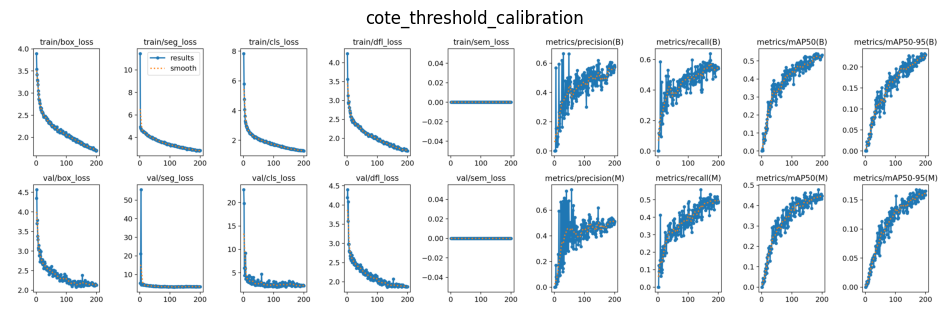

Inspecting selected best run in: /kaggle/working/runs/improving_full_and_labeled_test/cote_threshold_calibration


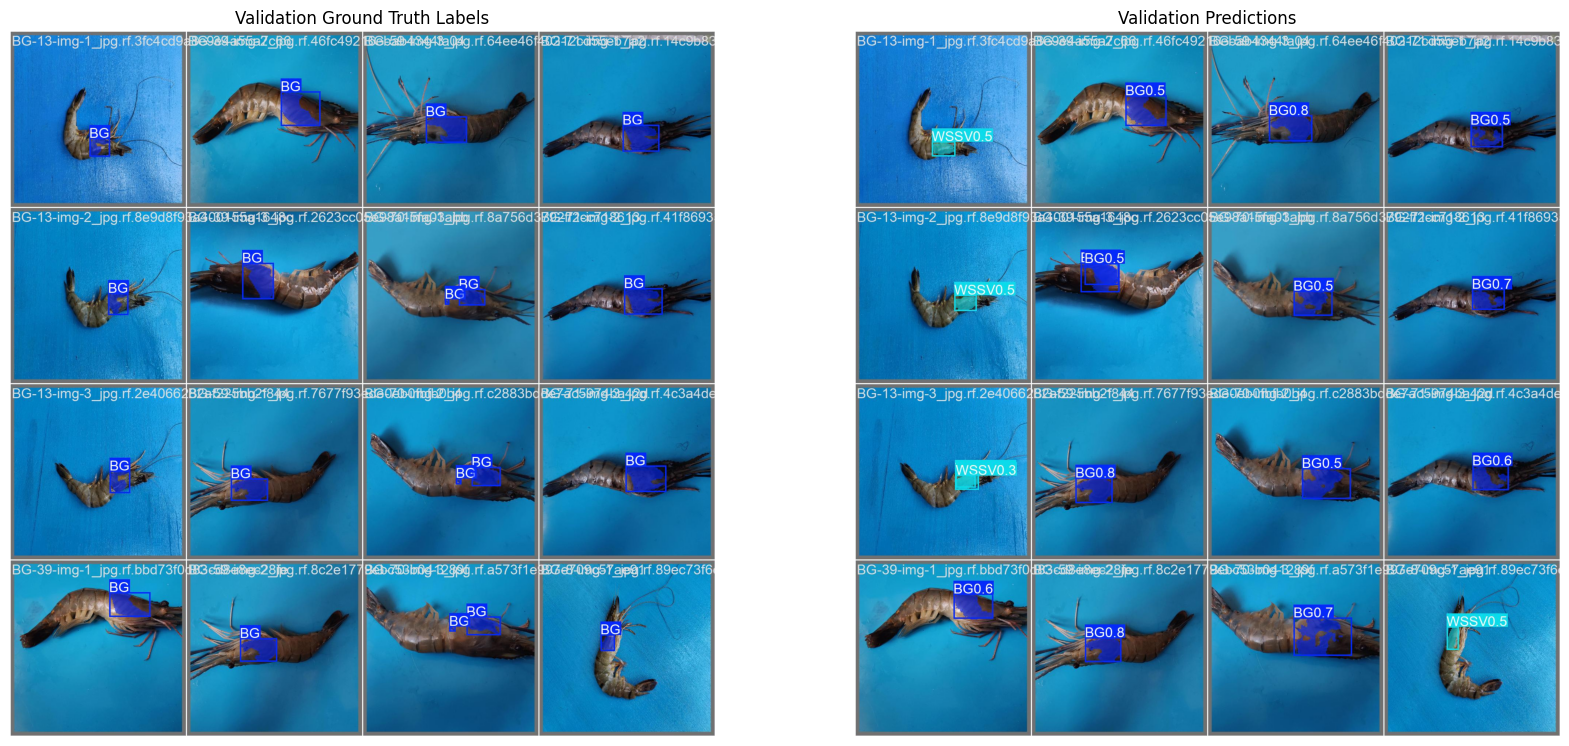

In [33]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path
from IPython.display import display

if 'results_df' not in globals():
    results_df = pd.read_csv(REPORT_DIR / f'{EXPERIMENT_NAME}_results_summary.csv')
    BEST_RUN = results_df.iloc[0].to_dict()
    run_path = BEST_RUN['run_path']
    best_model_path = BEST_RUN['best_pt']

print('Strong-augmentation attention summary:')
display(results_df)

inspect_cols = [
    'experiment',
    'epochs_ran',
    'best_epoch_by_mask_map50',
    'best_val_mask_map50',
    'labeled_val_mask_map50',
    'labeled_val_mask_count_mae',
    'labeled_val_disease_box_miss_rate',
    'healthy_val_mask_fp_rate',
    'healthy_aware_labeled_val_mask_map50',
    'labeled_test_mask_map50',
    'labeled_test_mask_count_mae',
    'labeled_test_disease_box_miss_rate',
    'healthy_test_mask_fp_rate',
    'full_test_image_wrong_total',
    'full_test_image_wrong_rate',
    'full_test_healthy_wrong_images',
    'full_test_bg_wrong_images',
    'full_test_wssv_wrong_images',
    'labeled_test_image_wrong_total',
    'labeled_test_image_wrong_rate',
    'labeled_test_bg_wrong_images',
    'labeled_test_wssv_wrong_images',
    'healthy_aware_labeled_test_mask_map50',
]
print('Validation-selected inspection columns:')
display(results_df[[c for c in inspect_cols if c in results_df.columns]])

for _, row in results_df.iterrows():
    current_run_path = Path(row['run_path'])
    results_png = current_run_path / 'results.png'
    print(f"\nMetrics plot for {row['run_name']}: {results_png}")
    if results_png.exists():
        plt.figure(figsize=(12, 12))
        plt.imshow(mpimg.imread(results_png))
        plt.axis('off')
        plt.title(row['run_name'])
        plt.show()

print(f'Inspecting selected best run in: {run_path}')
val_batch = Path(run_path) / 'val_batch0_labels.jpg'
val_pred = Path(run_path) / 'val_batch0_pred.jpg'
fig, ax = plt.subplots(1, 2, figsize=(20, 10))
if val_batch.exists():
    ax[0].imshow(mpimg.imread(val_batch))
    ax[0].set_title('Validation Ground Truth Labels')
else:
    ax[0].set_title('Validation Labels not found')
if val_pred.exists():
    ax[1].imshow(mpimg.imread(val_pred))
    ax[1].set_title('Validation Predictions')
else:
    ax[1].set_title('Validation Predictions not found')
for a in ax:
    a.axis('off')
plt.show()


### Test Set Evaluation, Healthy False Positives, and Visual Inspection
This block evaluates the selected best checkpoint on:
- the full test set,
- the diseased/labeled-only test subset,
- the healthy/empty-label test subset for false positives.

It then visualizes augmented training masks, diseased test predictions, and healthy test predictions so you can inspect both missed disease masks and false alarms on healthy shrimp.

The notebook now also prints image-level class prediction errors for the full test set, the labeled-only test set, and healthy-negative images.

In [ ]:
from ultralytics import YOLO
import glob
import matplotlib.pyplot as plt
import os
import random
from pathlib import Path
import pandas as pd

model_inference = YOLO(best_model_path)
selected_exp = BEST_RUN['experiment']
selected_dataset_dir = EXPERIMENT_ROOT / selected_exp / 'dataset'
selected_yaml = selected_dataset_dir / 'data.yaml'
selected_labeled_yaml = EXPERIMENT_ROOT / selected_exp / 'dataset_labeled_only_eval' / 'data_labeled_only.yaml'
selected_healthy_dir = EXPERIMENT_ROOT / selected_exp / 'dataset_healthy_only_eval'
selected_healthy_yaml = selected_healthy_dir / 'data_healthy_only.yaml'

print('Full test-set evaluation:')
full_test_metrics = model_inference.val(data=str(selected_yaml), split='test', imgsz=640, plots=True, verbose=False)
print('Labeled-only diseased test-set evaluation:')
labeled_test_metrics = model_inference.val(data=str(selected_labeled_yaml), split='test', imgsz=640, plots=False, verbose=False)
healthy_test_fp = healthy_false_positive_summary(model_inference, selected_healthy_dir / 'test' / 'images')

print('Full test mask mAP50:', metric_value(full_test_metrics, 'seg.map50'))
print('Labeled-only diseased test mask mAP50:', metric_value(labeled_test_metrics, 'seg.map50'))
print('Healthy test mask false-positive rate:', healthy_test_fp['healthy_mask_fp_rate'])
print('Healthy test false-positive masks per image:', healthy_test_fp['healthy_fp_masks_per_image'])

print('\nImage-level class error summaries at prediction conf:', PREDICT_CONF_FOR_COUNT)
full_test_class_errors = image_level_class_error_summary(
    model_inference,
    selected_dataset_dir / 'test' / 'images',
    selected_dataset_dir / 'test' / 'labels',
)
labeled_test_class_errors = image_level_class_error_summary(
    model_inference,
    selected_labeled_yaml.parent / 'test' / 'images',
    selected_labeled_yaml.parent / 'test' / 'labels',
)
print_image_level_class_errors('Full test image-level class error summary', full_test_class_errors)
print_image_level_class_errors('Labeled-only test image-level class error summary', labeled_test_class_errors)

full_error_csv = REPORT_DIR / f'{EXPERIMENT_NAME}_full_test_image_class_errors.csv'
labeled_error_csv = REPORT_DIR / f'{EXPERIMENT_NAME}_labeled_test_image_class_errors.csv'
pd.DataFrame(full_test_class_errors['class_rows']).to_csv(full_error_csv, index=False)
pd.DataFrame(labeled_test_class_errors['class_rows']).to_csv(labeled_error_csv, index=False)
print('Saved full-test image class errors:', full_error_csv)
print('Saved labeled-test image class errors:', labeled_error_csv)


def draw_yolo_segmentation_labels(image_path, label_path):
    image = cv2.imread(str(image_path))
    if image is None:
        raise FileNotFoundError(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    height, width = image.shape[:2]
    overlay = image.copy()
    colors = [(255, 70, 70), (70, 180, 255), (90, 220, 120), (240, 180, 60)]

    if label_path.exists():
        for line in label_path.read_text().splitlines():
            parts = line.strip().split()
            if len(parts) < 7:
                continue
            cls_id = int(float(parts[0]))
            coords = np.array([float(v) for v in parts[1:]], dtype=np.float32).reshape(-1, 2)
            coords[:, 0] *= width
            coords[:, 1] *= height
            pts = coords.astype(np.int32)
            color = colors[cls_id % len(colors)]
            cv2.polylines(overlay, [pts], isClosed=True, color=color, thickness=2)
            cv2.fillPoly(overlay, [pts], color=color)
            x, y = pts[0]
            label = class_names[cls_id] if cls_id < len(class_names) else str(cls_id)
            cv2.putText(overlay, label, (int(x), int(y)), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

    return cv2.addWeighted(overlay, 0.35, image, 0.65, 0)


# Visualize augmented training ground-truth masks directly.
aug_images = sorted((selected_dataset_dir / 'train' / 'images').glob('aug_*'))
random.seed(42)
aug_images = random.sample(aug_images, k=min(6, len(aug_images)))

if aug_images:
    fig, axes = plt.subplots(len(aug_images), 1, figsize=(10, 5 * len(aug_images)))
    if len(aug_images) == 1:
        axes = [axes]
    for ax, image_path in zip(axes, aug_images):
        label_path = selected_dataset_dir / 'train' / 'labels' / f'{image_path.stem}.txt'
        ax.imshow(draw_yolo_segmentation_labels(image_path, label_path))
        ax.set_title(f'Augmented train GT mask: {image_path.name} | label exists={label_path.exists()}')
        ax.axis('off')
    plt.show()
else:
    print('No augmented training images found to visualize.')

# Visualize labeled test predictions.
test_images = []
for ext in IMAGE_EXTENSIONS:
    test_images.extend((selected_dataset_dir / 'test' / 'images').glob(f'*{ext}'))

def has_nonempty_label(image_path):
    label_path = selected_dataset_dir / 'test' / 'labels' / f'{image_path.stem}.txt'
    return label_path.exists() and bool(label_path.read_text().strip())

test_images = [p for p in sorted(test_images) if has_nonempty_label(p)]
test_images = test_images[:8]

results = model_inference.predict(source=[str(p) for p in test_images], conf=0.1, save=True, verbose=False)
for image_path, result in zip(test_images, results):
    plt.figure(figsize=(8, 8))
    plt.imshow(result.plot())
    plt.title(f'Labeled test prediction: {image_path.name} (conf > 0.1)')
    plt.axis('off')
    plt.show()

# Visualize healthy negative predictions to inspect false positives.
healthy_images = []
for ext in IMAGE_EXTENSIONS:
    healthy_images.extend((selected_healthy_dir / 'test' / 'images').glob(f'*{ext}'))
healthy_images = sorted(healthy_images)[:8]

if healthy_images:
    healthy_results = model_inference.predict(source=[str(p) for p in healthy_images], conf=0.1, save=False, verbose=False)
    for image_path, result in zip(healthy_images, healthy_results):
        plt.figure(figsize=(8, 8))
        plt.imshow(result.plot())
        box_count = len(result.boxes) if result.boxes is not None else 0
        mask_count = len(result.masks) if result.masks is not None else 0
        plt.title(f'Healthy test prediction: {image_path.name} | boxes={box_count}, masks={mask_count}')
        plt.axis('off')
        plt.show()
else:
    print('No healthy test images found to visualize.')


Full test-set evaluation:
Ultralytics 8.4.98 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
cote_threshold_calibration summary (fused): 147 layers, 2,724,001 parameters, 0 gradients, 9.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3220.1±595.0 MB/s, size: 208.6 KB)
val: Scanning /kaggle/working/improving_full_and_labeled_test/outputs/cote_threshold_calibration/cote_threshold_calibration/dataset/test/labels.cache... 129 images, 41 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 129/129 54.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 2.1it/s 4.2s0.3ss
                   all        129        119      0.667      0.455      0.522      0.215      0.596      0.418      0.459      0.146
Speed: 4.4ms preprocess, 7.1ms inference, 0.0ms loss, 4.8ms postprocess per image
Results saved to /kaggle/working/runs/segment/val-11
Labeled-only diseased test-se

In [ ]:
print(f'Selected run path: {run_path}')
print(f'Selected checkpoint: {best_model_path}')
print(f'Report directory: {REPORT_DIR}')
print('Validation healthy-aware score = labeled_val_mask_map50 - COUNT_PENALTY_WEIGHT * labeled_val_mask_count_mae - DISEASE_MISS_PENALTY_WEIGHT * labeled_val_disease_box_miss_rate - HEALTHY_FP_PENALTY_WEIGHT * healthy_val_mask_fp_rate')
print('Strong augmentation = fliplr=0.5, flipud=0.3, hsv_h=0.05, hsv_s=0.5, hsv_v=0.4, degrees=10, translate=0.1, scale=0.5, erasing=0.15; mosaic/mixup/copy_paste/Albumentations disabled')
